# Verifiable Machine Learning

In [ ]:
# from google.colab import files
# import tensorflow as tf
# import numpy as np
# import pandas as pd
# from tensorflow.keras.layers import Dense
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.callbacks import EarlyStopping
# from sklearn.metrics import r2_score
# from keras import layers

# # Custom constraint for weight normalization between -1 and 1
# class WeightNormalization(tf.keras.constraints.Constraint):
#     def __init__(self, min_value=-1, max_value=1):
#         self.min_value = min_value
#         self.max_value = max_value

#     def __call__(self, w):
#         w = tf.cast(w, tf.float32)
#         w = tf.where(w < self.min_value, self.min_value * tf.ones_like(w), w)
#         w = tf.where(w > self.max_value, self.max_value * tf.ones_like(w), w)
#         return w

# # Load data from the existing files
# K_x = np.loadtxt("K_x.txt").reshape(-1, 1)  # Reshape as 2D input
# K_u = np.loadtxt("K_u.txt").reshape(-1, 1)  # Reshape as 2D output

# # Assign the loaded data to variables xs and us for training
# xs, us = K_x, K_u

# # Step 3: Define neural network architecture
# # model = Sequential()
# # model.add(Dense(10, input_dim=xs.shape[1], activation='tanh', use_bias=False, name='W1', kernel_constraint=WeightNormalization(min_value=-4, max_value=4)))
# # model.add(Dense(10, activation='tanh', use_bias=False, name='W2', kernel_constraint=WeightNormalization(min_value=-4, max_value=4)))
# # model.add(Dense(1, use_bias=False, name='W3', kernel_constraint=WeightNormalization(min_value=-4, max_value=4)))

# model = Sequential()
# model.add(Dense(10, input_dim=xs.shape[1], activation='tanh', use_bias=False, name='W1'))
# model.add(Dense(10, activation='tanh', use_bias=False, name='W2'))
# model.add(Dense(1, use_bias=False, name='W3'))

# opt = tf.keras.optimizers.Adam(learning_rate=0.01)

# # Compile the model
# model.compile(optimizer=opt, loss='mse')

# # Train the model
# epochs = 100
# batch_size = 32
# verbose = True
# validation_split = 0.0
# early = EarlyStopping(monitor='loss', min_delta=0.001, patience=10, verbose=1, restore_best_weights=True)

# model.fit(xs, us, epochs=epochs, batch_size=batch_size, verbose=verbose, validation_split=validation_split)

# # Step 4: Evaluate the model
# pred = model.predict(xs)
# r2 = r2_score(us, pred)
# print("R-squared:", r2)

# # Step 5: Save the transpose of the weights to CSV files
# for layer in model.layers:
#     layer_name = layer.name
#     weights_transpose = np.transpose(layer.get_weights()[0])
#     df = pd.DataFrame(weights_transpose, columns=[f'{layer_name}_{i}' for i in range(weights_transpose.shape[1])])
#     df.to_csv(f'{layer_name}.csv', index=False, header=False)
#     print(f"Transpose of weights for layer {layer_name} saved to {layer_name}.csv")


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Generate input data within the desired range
# x_range = np.linspace(-10, 10, 100)  # 100 points between -6 and 6
# x_range = x_range.reshape(-1, 1)  # Reshape for model input

# # Predict the output using the trained model
# model_output = model.predict(x_range)

# # Create the plot
# plt.figure(figsize=(8, 6))  # Adjust figure size as needed

# # Plot the model's output
# plt.plot(x_range, model_output, label='Model Output', color='blue')

# # Plot the lines -2x and -3x
# plt.plot(x_range, -2.06 * x_range, label='-2x', color='red', linestyle='--')
# plt.plot(x_range, -3 * x_range, label='-3x', color='green', linestyle='--')

# # Customize the plot
# plt.xlabel('Input (x)')
# plt.ylabel('Output')
# plt.title('Model Output vs. Input')
# plt.legend()
# plt.grid(True)

# # Display the plot
# plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
#     # Get the weights of each layer
# W1 = np.transpose(model.get_layer('W1').get_weights()[0])
# W2 = np.transpose(model.get_layer('W2').get_weights()[0])
# W3 = np.transpose(model.get_layer('W3').get_weights()[0])
# # W4 = np.transpose(model.get_layer('W4').get_weights()[0])


# # Perform matrix multiplication W4 * W3 * W2 * W1
# result_matrix =  np.abs(W3) @ np.abs(W2) @ np.abs(W1)

# # Print the result_matrix or use it as needed
# print("Result of multiplication W4 * W3 * W2 * W1:")
# print(result_matrix)

In [ ]:
import torch
import numpy as np
import cvxpy as cp
from enum import Enum
import matplotlib.pyplot as plt

In [ ]:
def nnet_to_weights_and_biases(nnet_filename: str) -> tuple[np.ndarray, np.ndarray]:
  # load a nnet text file and extract the weights and biases

  # converted this code from: https://github.com/sisl/NeuralVerification.jl/blob/957cb32081f37de57d84d7f0813f708288b56271/src/utils/util.jl#L10
  with open(nnet_filename, 'r') as f:
    line = f.readline()
    while "//" in line: #skip comments
      line = f.readline()
    # number of layers
    nlayers = int(line.strip().split(",")[0])
    # read in layer sizes
    layer_sizes = [int(x) for x in f.readline().split(",")[1:nlayers+1]]
    # read past additonal information
    for i in range(1, 6):
      line = f.readline()
    # i=1 corresponds to the input dimension, so it's ignored
    Ws = []
    bs = []
    for dim in layer_sizes:
      W = np.vstack([[float(x) for x in f.readline().rstrip(',\n ').split(",")] for i in range(dim)])
      b = np.array([float(f.readline().rstrip(',\n ')) for _ in range(dim)])
      Ws.append(W)
      bs.append(b)

  return Ws, bs

def weights_and_biases_to_pytorch(Ws: list[np.ndarray], bs: list[np.ndarray]) -> torch.nn.Sequential:
  # given weights and biases, create a torch.nn.Sequential model with relus
  # btwn each linear layer (except no activation on final layer)

  num_layers = len(Ws)

  layers = []
  for W, b in zip(Ws, bs):
    out_features, in_features = W.shape
    layer = torch.nn.Linear(in_features, out_features)
    layer.weight = torch.nn.Parameter(torch.Tensor(W))
    layer.bias = torch.nn.Parameter(torch.Tensor(b))
    layers.append(layer)
    layers.append(torch.nn.ReLU())

  # don't add ReLU to end of NN
  model = torch.nn.Sequential(*layers[:-1])
  return model

def nnet_to_pytorch(nnet_filename: str) -> torch.nn.Sequential:
  # directly convert from nnet text file to pytorch model
  Ws, bs = nnet_to_weights_and_biases(nnet_filename)
  model = weights_and_biases_to_pytorch(Ws, bs)
  return model

def model_to_weights_and_biases(model: torch.nn.Sequential) -> tuple[np.ndarray, np.ndarray]:
  # extract the weights and biases as numpy arrays from a torch.nn.Sequential model
  Ws = []
  bs = []
  for idx, m in enumerate(model.modules()):
    if isinstance(m, torch.nn.Sequential):
      continue
    elif isinstance(m, torch.nn.ReLU):
      continue
    elif isinstance(m, torch.nn.Linear):
      Ws.append(m.weight.data.numpy())
      bs.append(m.bias.data.numpy())
    else:
      print("That layer isn't supported.")
      assert 0
  return Ws, bs

In [ ]:
def nominal_and_epsilon_to_range(nominal: np.ndarray, epsilon: np.ndarray | float) -> np.ndarray:
  return np.vstack([nominal-epsilon, nominal+epsilon]).T

def range_to_nominal_and_epsilon(input_range: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
  nominal_input = (input_range[:, 1] + input_range[:, 0]) / 2.
  epsilon = (input_range[:, 1] - input_range[:, 0]) / 2.
  return nominal_input, epsilon

For example, to load a NN controller for a cartpole system, then query the controller for its action at a particular state:

In [ ]:
#two dimention input
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load your new data
# K_x = np.loadtxt("/content/Kx_x.txt", dtype=np.float32).reshape(-1, 2)  # Now 2-dimensional input
K_x = np.loadtxt("/content/Kx_x.txt", dtype=np.float32, delimiter=",").reshape(-1, 2)
K_u = np.loadtxt("/content/Kx_u.txt", dtype=np.float32).reshape(-1, 1)  # Output remains 1-dimensional

# Ensure the data shapes match
assert K_x.shape[0] == K_u.shape[0], f"Input and output rows must match, got {K_x.shape[0]} and {K_u.shape[0]}"

# Train-test split
K_x_train, K_x_test, K_u_train, K_u_test = train_test_split(
    K_x, K_u, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
K_x_train_tensor = torch.from_numpy(K_x_train)
K_u_train_tensor = torch.from_numpy(K_u_train)
K_x_test_tensor = torch.from_numpy(K_x_test)
K_u_test_tensor = torch.from_numpy(K_u_test)

# Adjusted Neural Network model (input dimension changed to 2)
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(2, 10, bias=False)  # Now accepts 2-dimensional input
        self.fc2 = nn.Linear(10, 10, bias=False)
        self.fc3 = nn.Linear(10, 1, bias=False)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize model, loss function, and optimizer
model = Net()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 1000
losses = []
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(K_x_train_tensor)
    loss = criterion(outputs, K_u_train_tensor)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}")

# Plot the training loss
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()

# Evaluate model on test data
model.eval()
with torch.no_grad():
    test_predictions = model(K_x_test_tensor).numpy()
    r2 = r2_score(K_u_test, test_predictions)

print(f"\nTest R² Score: {r2:.6f}")


ValueError: cannot reshape array of size 571 into shape (2)

In [ ]:
import os
import pandas as pd

# Ensure the directory exists
os.makedirs("model_weights", exist_ok=True)

# Loop through each layer and save weights as CSV
for name, param in model.named_parameters():
    param_numpy = param.detach().cpu().numpy()
    df = pd.DataFrame(param_numpy)
    csv_path = f"model_weights/{name.replace('.', '_')}.csv"
    df.to_csv(csv_path, index=False, header=False)
    print(f"Saved weights to: {csv_path}")


Saved weights to: model_weights/fc1_weight.csv
Saved weights to: model_weights/fc2_weight.csv
Saved weights to: model_weights/fc3_weight.csv


<frozen importlib._bootstrap>:1047: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import r2_score  # Import R² function

# Load data from text files
K_x = np.loadtxt("/content/K_x.txt", dtype=np.float32).reshape(-1, 1)
K_u = np.loadtxt("/content/K_u.txt", dtype=np.float32).reshape(-1, 1)

# Convert to PyTorch tensors
K_x_tensor = torch.from_numpy(K_x)
K_u_tensor = torch.from_numpy(K_u)

# Define a simple feedforward neural network
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(1, 10, bias = False)  # First hidden layer
        self.fc2 = nn.Linear(10, 10, bias = False)  # Second hidden layer
        self.fc3 = nn.Linear(10, 1, bias = False)  # Output layer

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize model, loss function, and optimizer
pytorch_model = Net()
criterion = nn.MSELoss()
optimizer = optim.Adam(pytorch_model.parameters(), lr=0.01)

# Training loop
epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = pytorch_model(K_x_tensor)
    loss = criterion(outputs, K_u_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}")

# Calculate R² Score
with torch.no_grad():
    predictions = pytorch_model(K_x_tensor)

    # Convert tensors to NumPy arrays for sklearn r2_score
    K_u_numpy = K_u_tensor.numpy()
    predictions_numpy = predictions.numpy()

    # Compute R² score
    r2 = r2_score(K_u_numpy, predictions_numpy)

print(f"\nFinal R² Score: {r2:.6f}")  # Display only R² score
pytorch_model.eval()

Epoch [0/1000], Loss: 9.505639
Epoch [100/1000], Loss: 0.585032
Epoch [200/1000], Loss: 0.153383
Epoch [300/1000], Loss: 0.089019
Epoch [400/1000], Loss: 0.063861
Epoch [500/1000], Loss: 0.050416
Epoch [600/1000], Loss: 0.041873
Epoch [700/1000], Loss: 0.036735
Epoch [800/1000], Loss: 0.033336
Epoch [900/1000], Loss: 0.028695

Final R² Score: 0.996612


Net(
  (fc1): Linear(in_features=1, out_features=10, bias=False)
  (fc2): Linear(in_features=10, out_features=10, bias=False)
  (fc3): Linear(in_features=10, out_features=1, bias=False)
)

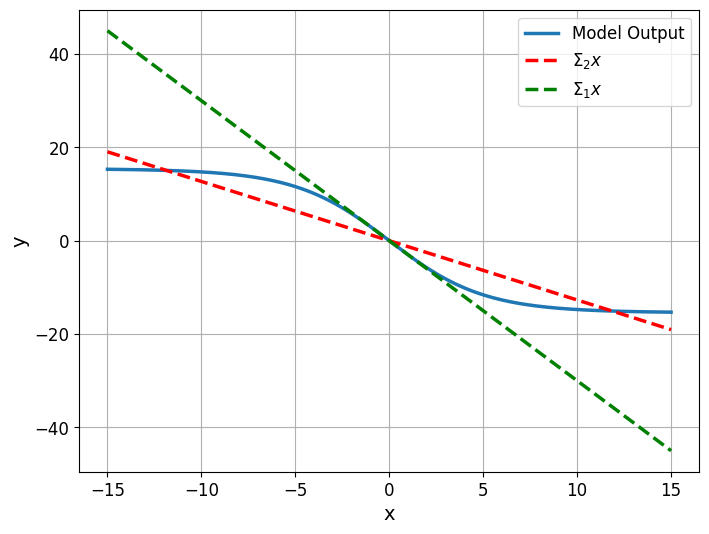

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Create a range of x values
x_values = np.linspace(-15, 15, 200).astype(np.float32).reshape(-1, 1)

# Compute model outputs without gradient tracking
pytorch_model.eval()
with torch.no_grad():
    x_tensor = torch.from_numpy(x_values)
    y_pred = pytorch_model(x_tensor).numpy().flatten()

# Convert x_values to a 1D array for plotting
x_values_1d = x_values.flatten()

# Create the plot
plt.figure(figsize=(8, 6))  # Adjust figure size as needed

# Plot the model predictions
plt.plot(x_values_1d, y_pred, label='Model Output', linewidth=2.5)

# Plot -2x and -3x with math-mode labels and thicker lines
plt.plot(x_values_1d, -1.27 * x_values_1d, label=r'$\Sigma_{2}x$', color='red', linestyle='--', linewidth=2.5)
plt.plot(x_values_1d, -3 * x_values_1d, label=r'$\Sigma_{1}x$', color='green', linestyle='--', linewidth=2.5)

# Add labels with larger font size
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)

# Increase tick label size
plt.tick_params(axis='both', which='major', labelsize=12)

# Add legend with larger font size
plt.legend(fontsize=12)

# Add grid
plt.grid(True)

# Save the plot in .eps format with high resolution
plt.savefig('model_output_plot.pdf', format='pdf', dpi=300)

# Display the plot
plt.show()


In [ ]:
import pandas as pd

# # Create a folder to store CSVs
import os
os.makedirs("model_weights", exist_ok=True)

# Loop over each parameter and save to CSV
for name, param in pytorch_model.named_parameters():
    param_numpy = param.detach().cpu().numpy()
    df = pd.DataFrame(param_numpy)
    csv_path = f"model_weights/{name.replace('.', '_')}.csv"
    df.to_csv(csv_path, index=False, header=False)
    print(f"Saved: {csv_path}")


Saved: model_weights/fc1_weight.csv
Saved: model_weights/fc2_weight.csv
Saved: model_weights/fc3_weight.csv


# Problem 5: Explore the `jax_verify` library for verification

There are a few excellent open-source libraries for NN verification. For example, `jax_verify` has implementations of IBP, CROWN, and many other algorithms. These methods can handle a broader class of NNs than just the ReLU NNs you worked with above, so they may be useful tools to leverage in your research or projects.

A big upside of `jax_verify` is that it supports JIT compilation, which can speed up verification algorithms by 10-100x (you don't need to set up JIT compilation for this assignment, but you're encouraged to try that out if you're curious).

Note that the `jax_verify` that is available by default in PyPi is an old version from 2020 that has a slightly different API - installing a more recent version is recommended as we do below.

In [ ]:
# Install my fork of jax_verify, which fixes a few deprecation errors in the mainline repo
!pip install git+https://gitlab.com/neu-autonomy/certifiable-learning/jax_verify@mainline_repo
import jax.numpy as jnp
import jax_verify
import functools

  Cloning https://gitlab.com/neu-autonomy/certifiable-learning/jax_verify (to revision mainline_repo) to /tmp/pip-req-build-cve4ydkl
  Running command git clone --filter=blob:none --quiet https://gitlab.com/neu-autonomy/certifiable-learning/jax_verify /tmp/pip-req-build-cve4ydkl
  Running command git checkout -b mainline_repo --track origin/mainline_repo
  Switched to a new branch 'mainline_repo'
  Branch 'mainline_repo' set up to track remote branch 'mainline_repo' from 'origin'.
  Resolved https://gitlab.com/neu-autonomy/certifiable-learning/jax_verify to commit 7cc6699a735023a905e6557475bc24354d96f525
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/deepmind/einshape.git to /tmp/pip-install-cm1y1sae/einshape_14e207b7d49a4fc78f316c65b6c4392e
  Running command git clone --filter=blob:none --quiet https://github.com/deepmind/einshape.git /tmp/pip-install-cm1y1sae/einshape_14e207b7d49a4fc78f316c65b6c4392e
  Resolved https://github.com/deepmind/einshape.git to commit

<frozen importlib._bootstrap>:1047: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _AltairImportHook.find_spec() not found; falling back to find_module()


Some utility methods that help set up the NN in jax:

In [ ]:
# def pytorch_model_to_jax(torch_model: torch.nn.Sequential):
#   params = []
#   act = None

#   # Extract params (weights, biases) from torch layers, to be used in
#   # jax.
#   # Note: This propagator assumes a feed-forward relu NN.
#   for m in torch_model.modules():
#     if isinstance(m, torch.nn.Sequential):
#       continue
#     elif isinstance(m, torch.nn.ReLU):
#       if act is None or act == "relu":
#         act = "relu"
#     elif isinstance(m, torch.nn.Linear):
#       w = m.weight.data.numpy().T
#       b = m.bias.data.numpy()
#       params.append((w, b))
#   return functools.partial(relu_nn, params)

# def relu_nn(params, inputs):
#   for W, b in params[:-1]:
#     outputs = jnp.dot(inputs, W) + b
#     inputs = jnp.maximum(outputs, 0)
#   W, b = params[-1]
#   return jnp.dot(inputs, W) + b

# def jax_interval_to_np_range(interval: jax_verify.IntervalBound) -> np.ndarray:
#   return np.vstack([interval.lower, interval.upper]).T

# def np_range_to_jax_interval(input_range: np.ndarray) -> jax_verify.IntervalBound:
#   return jax_verify.IntervalBound(input_range[:, 0], input_range[:, 1])

# jax_model = pytorch_model_to_jax(pytorch_model)

In [ ]:
# def pytorch_model_to_jax(torch_model: torch.nn.Sequential):
#   params = []
#   act = None

#   # Extract params (weights, biases) from torch layers, to be used in
#   # jax.
#   # Note: This propagator assumes a feed-forward relu NN.
#   for m in torch_model.modules():
#     if isinstance(m, torch.nn.Sequential):
#       continue
#     elif isinstance(m, torch.nn.ReLU):
#       if act is None or act == "relu":
#         act = "relu"
#     elif isinstance(m, torch.nn.Linear):
#       w = m.weight.data.numpy().T
#       b = m.bias.data.numpy()
#       params.append((w, b))
#   return functools.partial(relu_nn, params)

# def relu_nn(params, inputs):
#   for W, b in params[:-1]:
#     outputs = jnp.dot(inputs, W) + b
#     inputs = jnp.maximum(outputs, 0)
#   W, b = params[-1]
#   return jnp.dot(inputs, W) + b

# def jax_interval_to_np_range(interval: jax_verify.IntervalBound) -> np.ndarray:
#   return np.vstack([interval.lower, interval.upper]).T

# def np_range_to_jax_interval(input_range: np.ndarray) -> jax_verify.IntervalBound:
#   return jax_verify.IntervalBound(input_range[:, 0], input_range[:, 1])

# jax_model = pytorch_model_to_jax(pytorch_model)

In [ ]:
import functools
import torch
import jax
import jax.numpy as jnp

# Function to convert PyTorch model to JAX model
def pytorch_model_to_jax(torch_model: torch.nn.Module):
    params = []

    # Extract params (weights) from PyTorch layers
    for layer in torch_model.children():
        if isinstance(layer, torch.nn.Linear):
            w = layer.weight.detach().numpy().T  # Transpose for JAX compatibility
            params.append(w)

    return functools.partial(tanh_nn, params)

# JAX neural network with tanh activation
def tanh_nn(params, inputs):
    for W in params[:-1]:
        inputs = jnp.tanh(jnp.dot(inputs, W))  # Use tanh activation
    return jnp.dot(inputs, params[-1])  # Final linear layer (no activation)

# Convert the PyTorch model to JAX
jax_model = pytorch_model_to_jax(pytorch_model)


# Function to convert JAX interval to NumPy range
def jax_interval_to_np_range(interval: jax_verify.IntervalBound) -> np.ndarray:
    return np.vstack([interval.lower, interval.upper]).T

# Function to convert NumPy range to JAX interval
def np_range_to_jax_interval(input_range: np.ndarray) -> jax_verify.IntervalBound:
    return jax_verify.IntervalBound(input_range[:, 0], input_range[:, 1])


# Test conversion
x_test = jnp.array([[0.5]])  # Example input
print("JAX Model Output:", jax_model(x_test))


JAX Model Output: [[-1.4422262]]


In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np

# Define input range
x_range = jnp.linspace(-10, 10, 200).reshape(-1, 1)

# Compute JAX model output
jax_outputs = jax_model(x_range)

# Compute linear functions
linear_2x = -2.06 * x_range
linear_3x = -3 * x_range

# Convert to NumPy for plotting
x_range_np = np.array(x_range).flatten()
jax_outputs_np = np.array(jax_outputs).flatten()
linear_2x_np = np.array(linear_2x).flatten()
linear_3x_np = np.array(linear_3x).flatten()

# Plot results
plt.figure(figsize=(8, 6))
plt.plot(x_range_np, jax_outputs_np, label="JAX NN Output", linewidth=2)
plt.plot(x_range_np, linear_2x_np, label="-2.06x", linestyle="dashed")
plt.plot(x_range_np, linear_3x_np, label="-3x", linestyle="dotted")

plt.xlabel("Input (x)")
plt.ylabel("Output")
plt.title("JAX Neural Network Output vs Linear Functions")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'jax_model' is not defined

In [ ]:
import functools
import torch
import jax.numpy as jnp

# Function to convert PyTorch model to JAX model with tanh activations
def pytorch_model_to_jax(torch_model: torch.nn.Sequential):
    params = []
    act = None

    # Extract params (weights, biases) from PyTorch layers
    for m in torch_model.modules():
        if isinstance(m, torch.nn.Sequential):
            continue
        elif isinstance(m, torch.nn.Tanh):  # Check for Tanh activation
            if act is None or act == "tanh":
                act = "tanh"
        elif isinstance(m, torch.nn.Linear):
            w = m.weight.data.numpy().T
            b = m.bias.data.numpy()
            params.append((w, b))

    return functools.partial(tanh_nn, params)

# JAX neural network with tanh activation
def tanh_nn(params, inputs):
    for W, b in params[:-1]:
        outputs = jnp.dot(inputs, W) + b
        inputs = jnp.tanh(outputs)  # Use tanh activation
    W, b = params[-1]
    return jnp.dot(inputs, W) + b

# Function to convert JAX interval to NumPy range
def jax_interval_to_np_range(interval: jax_verify.IntervalBound) -> np.ndarray:
    return np.vstack([interval.lower, interval.upper]).T

# Function to convert NumPy range to JAX interval
def np_range_to_jax_interval(input_range: np.ndarray) -> jax_verify.IntervalBound:
    return jax_verify.IntervalBound(input_range[:, 0], input_range[:, 1])

# Convert the PyTorch model to JAX
jax_model = pytorch_model_to_jax(pytorch_model)


AttributeError: 'NoneType' object has no attribute 'data'

An example of using jax_verify's implementation of IBP on our NN

In [ ]:
# Load the NNet file and pass a nominal input to get the class logits
nominal_input = torch.Tensor([[5]]) # these 1 values correspond to the 4 states in cartpole
# Also set up an example set of possible inputs to this NN
epsilon = 5 # epsilon can be a scalar or a vec w/ same shape as nominal_input
input_range = nominal_and_epsilon_to_range(nominal_input, epsilon)
print(f"{input_range=}")

input_range=array([[ 0., 10.]], dtype=float32)


In [ ]:
# Example of a fwd pass on the NN using jax
nominal_output_jax = jax_model(jnp.array(nominal_input))

# Example of computing bounds using IBP as implemented by jax_verify
input_bounds = np_range_to_jax_interval(input_range)
output_bounds_ibp_jax = jax_verify.backward_crown_bound_propagation(
    jax_model, input_bounds)
# output_bounds_ibp_jax = jax_verify.interval_bound_propagation(
    # jax_model, input_bounds)
output_range_ibp_jax = jax_interval_to_np_range(output_bounds_ibp_jax)
print(f"output bounds via backward_crown (jax_verify): \n{output_range_ibp_jax}")

NameError: name 'jax_model' is not defined

Does that output match the output of your IBP implementation?

Now for your job: take a look at jax_verify's documentation to see how to use the backward CROWN verifier.

**Deliverables:**

- output bounds using backward CROWN, rather than IBP

Number of funs: 
1
coeffs: 
[[nan]
 [nan]]
offset: 
[nan nan]


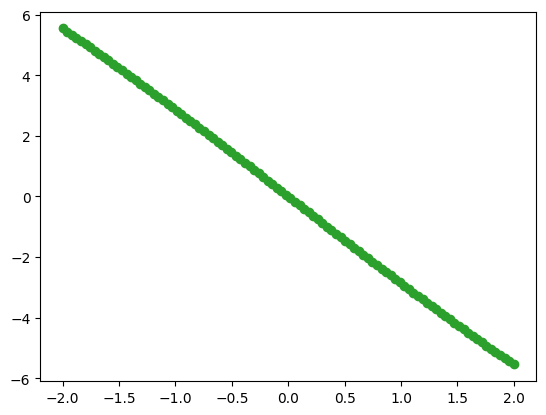

In [ ]:
from typing import Mapping, Optional, Sequence, Tuple
import functools, time
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax_verify

from jax_verify.src import (
    bound_propagation,
    graph_traversal,
    bound_utils,
    concretization,
    synthetic_primitives,
)
from jax_verify.src.linear import backward_crown, linear_relaxations

class LinFunExtractionConcretizer(concretization.BackwardConcretizer):
    """Linear function extractor.

    Given an objective over an output, extract the corresponding linear
    function over a target node.
    The relation between the output node and the target node are obtained by
    propagating backward the `base_transform`.
    """

    def __init__(self, base_transform, target_index, obj):
        self._base_transform = base_transform
        self._target_index = target_index
        self._obj = obj

    def should_handle_as_subgraph(self, primitive):
        return self._base_transform.should_handle_as_subgraph(primitive)

    def concretize_args(self, primitive):
        return self._base_transform.concretize_args(primitive)

    def concrete_bound(self, graph, inputs, env, node_ref):
        initial_lin_expression = linear_relaxations.LinearExpression(
            self._obj, jnp.zeros(self._obj.shape[:1])
        )

        target_linfun, _ = graph.backward_propagation(
            self._base_transform,
            env,
            {node_ref: initial_lin_expression},
            [self._target_index],
        )
        return target_linfun

def backward_crown_bound_propagation_linfun(
    function,
    *bounds,
    obj=None,
):
    """Run CROWN but return linfuns rather than concretized IntervalBounds.

    Args:
      function: Function performing computation to obtain bounds for. Takes as
        only argument the network inputs.
      *bounds: jax_verify.IntervalBound, bounds on the inputs of the function.
      obj: Tensor describing facets of function's output to bound
    Returns:
      output_bound: Bounds on the output of the function obtained by FastLin
    """

    # As we want to extract some linfuns that are in the middle of two linear
    # layers, we want to avoid the linear operator fusion.
    simplifier_composition = synthetic_primitives.simplifier_composition
    default_simplifier_without_linear = simplifier_composition(
        synthetic_primitives.activation_simplifier,
        synthetic_primitives.hoist_constant_computations,
        synthetic_primitives.group_posbilinear,
    )

    # We are first going to obtain intermediate bounds for all the activation
    # of the network, so that the backward propagation of the extraction can be
    # done.
    crown_algorithm = concretization.BackwardConcretizingAlgorithm(
        backward_crown.backward_crown_concretizer
    )
    # BoundRetrieverAlgorithm wraps an existing algorithm and captures all of
    # the intermediate bound it generates.
    bound_retriever_algorithm = bound_utils.BoundRetrieverAlgorithm(
        crown_algorithm
    )
    bound_propagation.bound_propagation(
        bound_retriever_algorithm,
        function,
        *bounds,
        graph_simplifier=default_simplifier_without_linear,
    )
    intermediate_bounds = bound_retriever_algorithm.concrete_bounds
    # Now that we have extracted all intermediate bounds, we create a
    # FixedBoundApplier. This is a forward transform that pretends to compute
    # bounds, but actually just look them up in a dict of precomputed bounds.
    fwd_bound_applier = bound_utils.FixedBoundApplier(intermediate_bounds)

    # Let's define what node we are interested in capturing linear functions
    # for. If needed, this could be extracted and given as argument to this
    # function, or as a callback that would compute which nodes to target.
    input_indices = [(i,) for i, _ in enumerate(bounds)]
    if False:  # TODO: add proper class type
        # TODO: add proper class type
        # if isinstance(bounds[0], 'simplex_bound'):
        # In the case we're using a Simplex bound, we also added a linear
        # layer to the front of the NN. So, stop backpropagating when you reach
        # that new linear layer, and you'll get the linfun relating polytope
        # coordinates to output.
        # We're identifying it because it's the first node that is not an input
        # bound
        for node_key in intermediate_bounds:
            if node_key not in input_indices:
                target_index = node_key
                break
    else:
        # We're propagating to the first input.
        target_index = input_indices[0]

    # Create the concretizer. See the class definition above. The definition
    # of a "concretized_bound" for this one is "Obj linear function
    # reformulated as a linear function of target index".
    # Note: If there is a need to handle a network with multiple output, it
    # should be easy to extend by making obj here a dict mapping output node to
    # objective on that output node.
    extracting_concretizer = LinFunExtractionConcretizer(
        backward_crown.backward_crown_transform, target_index, obj
    )

    # BackwardAlgorithmForwardConcretization uses:
    #  - A forward transform to compute all intermediate bounds (here a bound
    #    applier that just look them up).
    #  - A backward concretizer to compute all final bounds (which we have here
    #    defined as the linear function of the target index).
    fwd_bwd_alg = concretization.BackwardAlgorithmForwardConcretization
    lin_fun_extractor_algorithm = fwd_bwd_alg(
        fwd_bound_applier, extracting_concretizer
    )
    # We get one target_linfuns per output.
    target_linfuns, _ = bound_propagation.bound_propagation(
        lin_fun_extractor_algorithm,
        function,
        *bounds,
        graph_simplifier=default_simplifier_without_linear,
    )

    return target_linfuns

#@jax.jit
@functools.partial(jax.jit, static_argnums=(0,))                                    # this is also a jittable function
def jitted_linfun(fun, inp_bound, *params):                                         # (leverages your gpu if you're running this function a lot)
    inp_bound, = bound_propagation.unjit_inputs(inp_bound)
    linfuns = (
                backward_crown_bound_propagation_linfun(
                    fun, *params, inp_bound, obj=jnp.array([1.0, -1.0])

                )
            )
    return linfuns[0].lin_coeffs, linfuns[0].offset


if __name__ == "__main__":
    # x_bound = jax_verify.IntervalBound(jnp.array([-2.0]), jnp.array([2.0]))         # range we care about
    # y = 2                                                                           # not all parameters need to be ranges

    obj=jnp.array([[1.0], [-1.0]])                                                  # Controls the shape of the linear functions we want, has to be the shape of
                                                                                    # the output (stacked since we are doing upper and lower at the same time)

    linfuns = backward_crown_bound_propagation_linfun(jax_model, input_bounds, obj=obj)

    # this is what the structure of the output is
    print(f'Number of funs: \n{len(linfuns)}')                                      # just one linfun cause we're only extracting the terminal layer's functions
    print(f'coeffs: \n{linfuns[0].lin_coeffs}')                                     # should be shape of the input
    print(f'offset: \n{linfuns[0].offset}')                                         # should be shape of the output



    plt.figure('Bounds')
    samples = jnp.linspace(input_bounds.lower, input_bounds.upper, 100)
    sample_outs = [jax_model(sample) for sample in samples]
    plt.plot(samples, linfuns[0].lin_coeffs[0] * samples + linfuns[0].offset[0])    # lower bound
    plt.plot(samples, -(linfuns[0].lin_coeffs[1] * samples + linfuns[0].offset[1])) # upper bound (comes out as negative upper bound)
    plt.plot(samples, sample_outs, 'o')
    plt.show()


# Problem 6: Explore the `auto-LiRPA` library for verification

`auto-LiRPA` is a verification library based on PyTorch and one of the main developers was a Northeastern PhD student (Kaidi Xu)!

Just like with the previous problem, the next cells show you how to install the package and run IBP, then we ask you to look into their documentation and run backward CROWN on the same problem.

**Note:** I suggest doing this part last, because pip may try to downgrade the version of pytorch installed to satisfy requirements. You may also need to restart your kernel after the pip install. If you're on Colab and things seem messed up, you can always do `Runtime > Disconnect and delete runtime` (stronger than restarting the runtime, which doesn't reset to the default set of installed packages).

In [ ]:
!git clone https://github.com/Verified-Intelligence/auto_LiRPA.git
%cd auto_LiRPA
!pip install .

Cloning into 'auto_LiRPA'...
remote: Enumerating objects: 1028, done.
remote: Counting objects: 100% (229/229), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 1028 (delta 176), reused 119 (delta 119), pack-reused 799 (from 1)
Receiving objects: 100% (1028/1028), 34.16 MiB | 22.89 MiB/s, done.
Resolving deltas: 100% (640/640), done.
/content/auto_LiRPA
Processing /content/auto_LiRPA
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.4/337.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.5/522.5 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.2/779.2 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.5 MB/s e

In [ ]:
# Example input value (as a float)
x_test = np.array([[10]], dtype=np.float32)  # Replace 0.5 with your desired test input

# Convert to PyTorch tensor
x_tensor = torch.from_numpy(x_test)

# Set the model to evaluation mode (already done above, but good to repeat)
pytorch_model.eval()

# Disable gradient computation for inference
with torch.no_grad():
    y_output = pytorch_model(x_tensor)

print(f"Input: {x_test[0][0]}, NN Output: {y_output.item():.6f}")


Input: 10.0, NN Output: -15.051933


In [ ]:
# Load the NNet file and pass a nominal input to get the class logits
nominal_input = torch.Tensor([[5]]) # these 1 values correspond to the 4 states in cartpole
# Also set up an example set of possible inputs to this NN
epsilon = 5 # epsilon can be a scalar or a vec w/ same shape as nominal_input
input_range = nominal_and_epsilon_to_range(nominal_input, epsilon)
print(f"{input_range=}")

input_range=array([[ 0., 10.]], dtype=float32)


An example of using jax_verify's implementation of IBP on our cartpole control NN:

In [ ]:
from auto_LiRPA import BoundedModule, BoundedTensor, PerturbationLpNorm

# Wrap the model with auto_LiRPA.
model = BoundedModule(pytorch_model, torch.Tensor(nominal_input))
# Define perturbation. Here we add Linf perturbation to input data.
ptb = PerturbationLpNorm(norm=np.inf, eps=torch.Tensor([epsilon]))
# Make the input a BoundedTensor with the pre-defined perturbation.
my_input = BoundedTensor(torch.Tensor(nominal_input), ptb)
# Regular forward propagation using BoundedTensor works as usual.
prediction = model(my_input)
# Compute LiRPA bounds using IBP
lb, ub = model.compute_bounds(x=(my_input,), method="alpha-CROWN")
output_range_ibp_autolirpa = np.vstack([lb.detach().numpy(), ub.detach().numpy()]).T
print(f"output bounds via IBP (auto-lirpa): \n{output_range_ibp_autolirpa}")

Early stop at 13th iter due to 10 iterations no improvement!
output bounds via IBP (auto-lirpa): 
[[-1.4746428e+01 -1.8726480e-07]]


Does that match your implementation of IBP? What about `jax_verify`'s?

Now for your job: compute output bounds using `auto-LiRPA`'s implementation of backward CROWN

**Deliverables:**

- output bounds using backward CROWN, rather than IBP

All done!